KELOMPOK 5 MINGGU 5
- Fenniya Angel Lee M0501261094
- Husnul Amira M0501251059
- Kinanti Rizky Pangestutik M0501251038

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

**1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.**

In [ ]:
np.random.seed(191)
ar1 = np.array([1])
ma1 = np.array([1, -0.6])
ma_object1 = ArmaProcess(ar1,ma1)
ma1 = ma_object1.generate_sample(nsample=120)

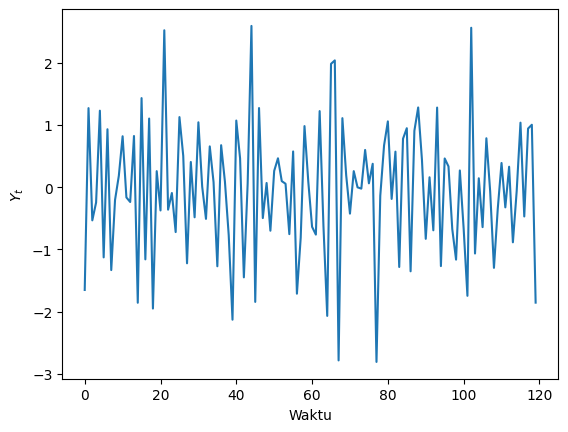

In [ ]:
plt.figure()
plt.plot(ma1)
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.show()

In [ ]:
# Simulasi Manual

np.random.seed(191)
theta=0.6
et=[np.random.normal(0,1)]
ma1_m=[]
for i in range(120):
    et.append(np.random.normal(0,1))
    ma1_m.append(et[i+1]-theta*et[i])

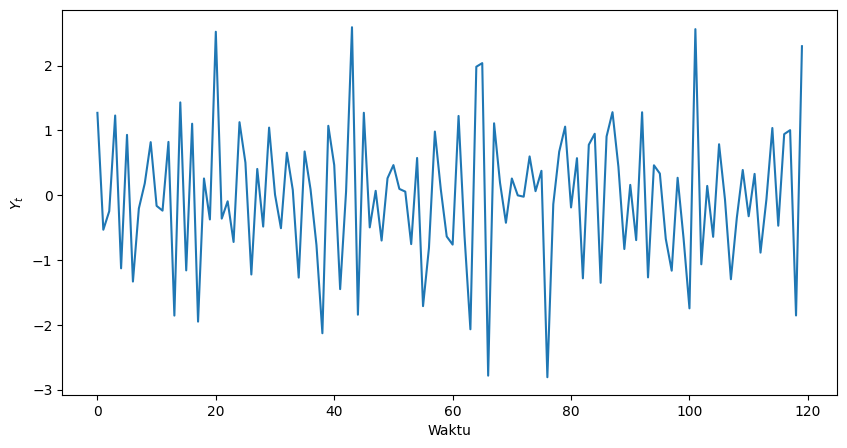

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ma1_m)
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.show()

**2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).**

Jumlah data latih: 96
Jumlah data uji: 24


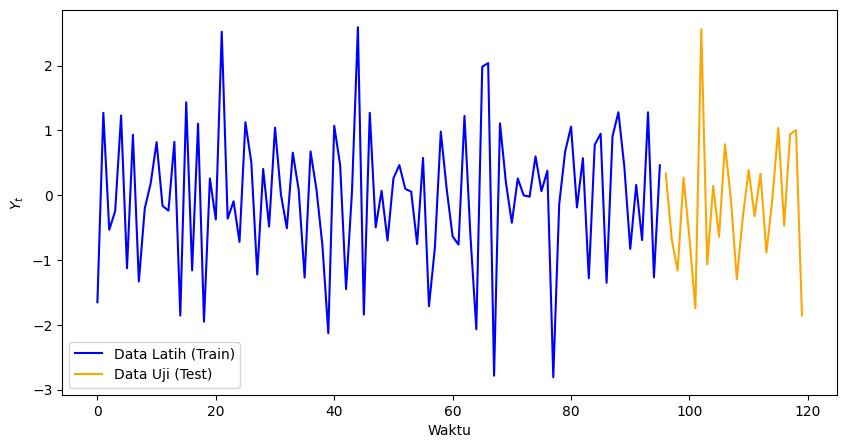

In [ ]:
# Menentukan proporsi pembagian data (misalnya 80% data latih, 20% data uji)
n_train = int(len(ma1) * 0.8)

# Membagi deret waktu secara sekuensial (tidak boleh diacak)
train_data = ma1[:n_train]
test_data = ma1[n_train:]

print(f"Jumlah data latih: {len(train_data)}")
print(f"Jumlah data uji: {len(test_data)}")

# Plot hasil pembagian data latih dan data uji
plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_train), train_data, label='Data Latih (Train)', color='blue')
plt.plot(np.arange(n_train, len(ma1)), test_data, label='Data Uji (Test)', color='orange')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.legend()
plt.show()

**3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.**

In [ ]:
# 1. Menginstal library PythonTsa
!pip install PythonTsa

# 2. Memuat ekstensi R agar bisa menggunakan magic command %%R
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


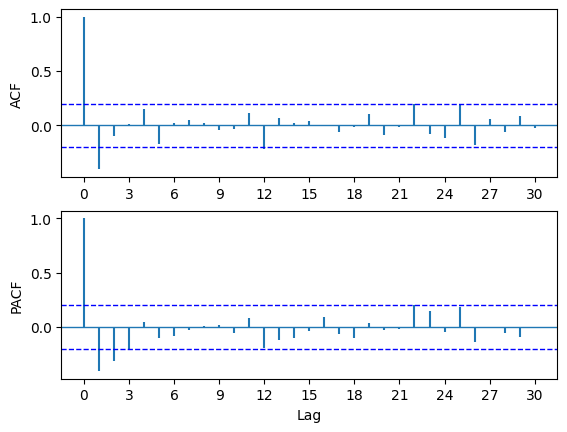

In [ ]:
from PythonTsa.plot_acf_pacf import acf_pacf_fig
import matplotlib.pyplot as plt

# Membuat plot ACF dan PACF dari data latih
acf_pacf_fig(train_data, both=True, lag=30)
plt.show()

In [ ]:
%%R
install.packages('TSA')
library (TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'
Content type 'application/x-gzip' length 207505 bytes (202 KB)
downloaded 202 KB


The downloaded source packages are in
	‘/tmp/RtmpK44omj/downloaded_packages’


In [ ]:
%%R -i train_data

# Membuat plot EACF dari data latih
eacf(as.numeric(train_data))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  o  o  o 
1 x o o o o o o o o o o  x  o  o 
2 x o x o o o o o o o o  x  o  o 
3 o o x o o o o o o o o  x  o  o 
4 x x x o o o o o o o o  x  o  o 
5 x o o o o o o o o o o  x  o  o 
6 x o o o o o o o o o o  o  o  o 
7 o o o o o o o o o o o  x  o  o 


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Melakukan pengepasan model MA(1) / ARIMA(0,0,1) pada data latih
model_fit = ARIMA(train_data, order=(0, 0, 1)).fit()

# Menampilkan ringkasan hasil model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -128.155
Date:                Wed, 23 Sep 2026   AIC                            262.310
Time:                        03:20:32   BIC                            270.003
Sample:                             0   HQIC                           265.420
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0188      0.036     -0.529      0.597      -0.088       0.051
ma.L1         -0.6435      0.080     -8.065      0.000      -0.800      -0.487
sigma2         0.8407      0.114      7.390      0.0

**4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.**

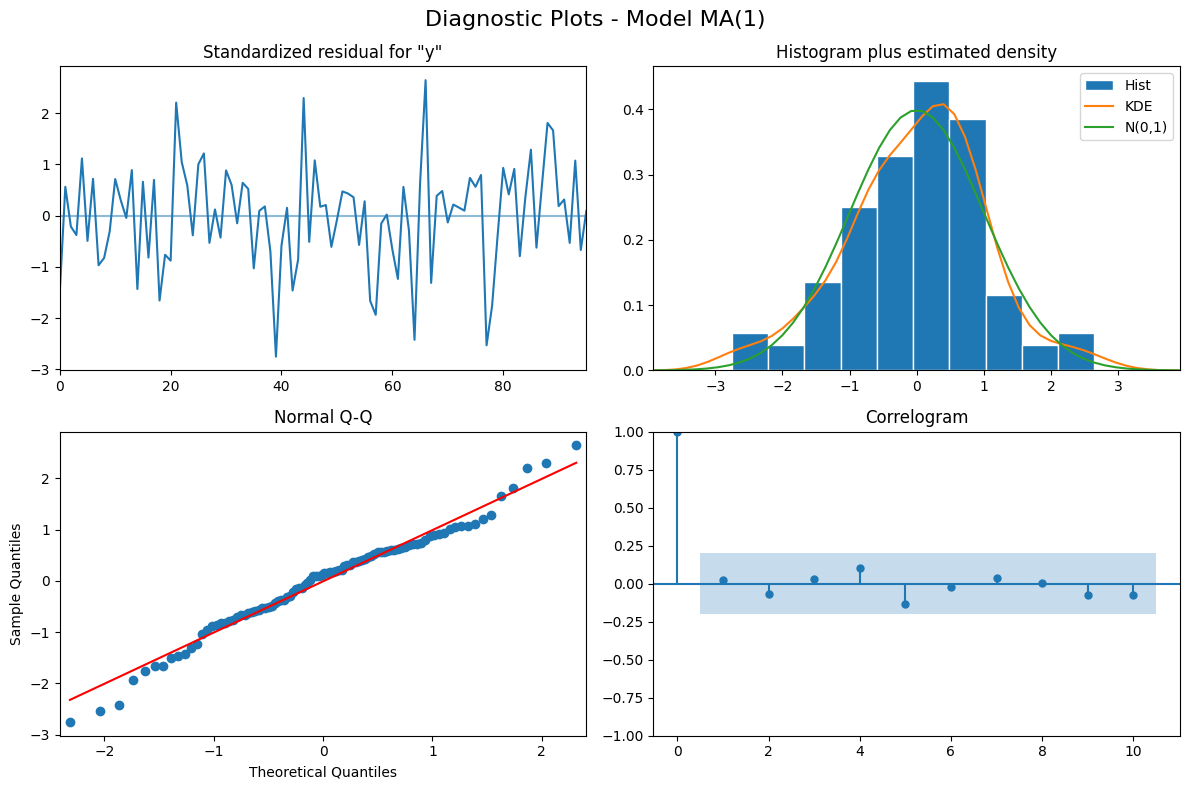

--- Hasil Overfitting ke MA(2) ---
[5.92759813e-01 5.79265374e-10 6.39679265e-01 1.38531621e-10]

--- Hasil Overfitting ke ARMA(1,1) ---
[5.93742878e-01 6.87303893e-01 1.97534129e-08 5.25963853e-11]

--- Perbandingan Kriteria Kebaikan Model ---
                   Model        AIC        BIC
    MA(1) / ARIMA(0,0,1) 262.310405 270.003450
    MA(2) / ARIMA(0,0,2) 264.128781 274.386173
ARMA(1,1) / ARIMA(1,0,1) 264.160332 274.417725


In [ ]:
import pandas as pd

# ==========================================
# 1. Pengecekan Diagnostik Sisaan
# ==========================================
# Memunculkan 4 plot diagnostik utama (Standardized residual, Histogram plus KDE, Normal Q-Q, dan Correlogram)
fig = model_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle('Diagnostic Plots - Model MA(1)', fontsize=16)
plt.tight_layout()
plt.show()


# ==========================================
# 2. Overfitting (Pengepasan Model Berlebih)
# ==========================================
# Model asli kita adalah MA(1) atau ARIMA(0,0,1).
# Kita overfit ke MA(2) [ARIMA(0,0,2)] dan ARMA(1,1) [ARIMA(1,0,1)]
model_ma2 = ARIMA(train_data, order=(0, 0, 2)).fit()
model_arma11 = ARIMA(train_data, order=(1, 0, 1)).fit()

print("--- Hasil Overfitting ke MA(2) ---")
# Menampilkan P-Value dari MA(2) untuk melihat apakah penambahan parameter signifikan
print(model_ma2.pvalues)
print("\n--- Hasil Overfitting ke ARMA(1,1) ---")
print(model_arma11.pvalues)


# ==========================================
# 3. Penentuan Model Terbaik (AIC & BIC)
# ==========================================
# Mengumpulkan nilai AIC dan BIC ke dalam DataFrame agar rapi
criteria_data = {
    'Model': ['MA(1) / ARIMA(0,0,1)', 'MA(2) / ARIMA(0,0,2)', 'ARMA(1,1) / ARIMA(1,0,1)'],
    'AIC': [model_fit.aic, model_ma2.aic, model_arma11.aic],
    'BIC': [model_fit.bic, model_ma2.bic, model_arma11.bic]
}

df_criteria = pd.DataFrame(criteria_data)
print("\n--- Perbandingan Kriteria Kebaikan Model ---")
print(df_criteria.to_string(index=False))

In [ ]:
import statsmodels.api as sm

# Uji Ljung-Box untuk sisaan model pada lag 5, 10, dan 15
ljung_box_results = sm.stats.acorr_ljungbox(model_fit.resid, lags=[5, 10, 15], return_df=True)
print(ljung_box_results)

      lb_stat  lb_pvalue
5    3.376325   0.642178
10   4.812364   0.903355
15  11.551437   0.712615


**5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.**

RMSE Data Latih : 0.9216
MAPE Data Latih : 300.4246%
RMSE Data Uji   : 0.9946
MAPE Data Uji   : 98.7307%


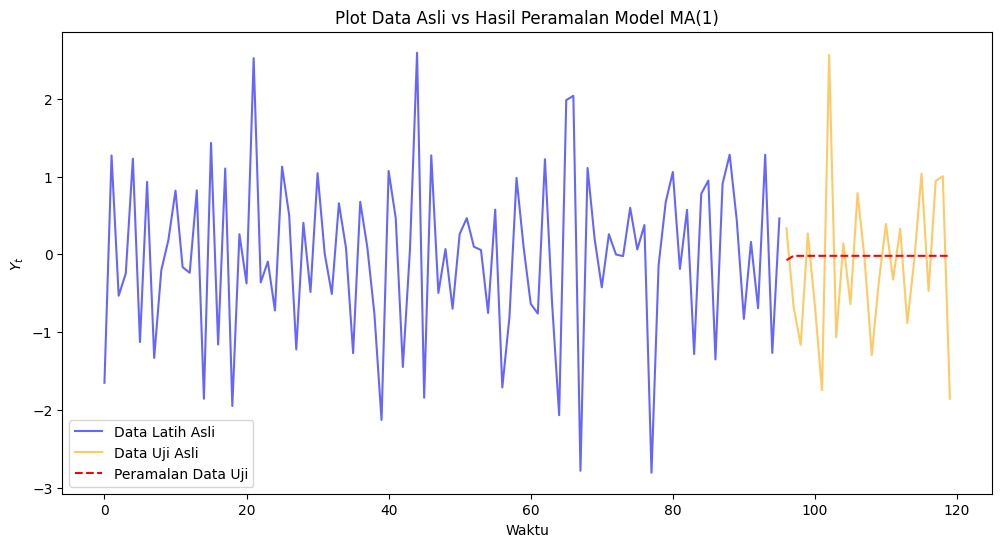

In [ ]:
# 1. Peramalan (Forecasting)
# Prediksi untuk data latih (Fitted values)
train_pred = model_fit.fittedvalues

# Prediksi untuk data uji sebanyak jumlah data uji (24 periode)
test_pred = model_fit.forecast(steps=len(test_data))

# 2. Fungsi Evaluasi Metrik
def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))

def calculate_mape(actual, predicted):
    # Menambahkan epsilon kecil (1e-10) untuk menghindari pembagian dengan nol
    return np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100

# Menghitung Metrik
rmse_train = calculate_rmse(train_data, train_pred)
mape_train = calculate_mape(train_data, train_pred)

rmse_test = calculate_rmse(test_data, test_pred)
mape_test = calculate_mape(test_data, test_pred)

print(f"RMSE Data Latih : {rmse_train:.4f}")
print(f"MAPE Data Latih : {mape_train:.4f}%")
print(f"RMSE Data Uji   : {rmse_test:.4f}")
print(f"MAPE Data Uji   : {mape_test:.4f}%")

# 3. Visualisasi Hasil Peramalan
plt.figure(figsize=(12, 6))
# Plot Data Asli
plt.plot(np.arange(len(train_data)), train_data, label='Data Latih Asli', color='blue', alpha=0.6)
plt.plot(np.arange(len(train_data), len(ma1)), test_data, label='Data Uji Asli', color='orange', alpha=0.6)

# Plot Hasil Prediksi (Hanya Data Uji)
plt.plot(np.arange(len(train_data), len(ma1)), test_pred, label='Peramalan Data Uji', color='red', linestyle='--')

plt.title('Plot Data Asli vs Hasil Peramalan Model MA(1)')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.legend()
plt.show()

**DERET AR(2)**

**1. Simulasikan deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$**

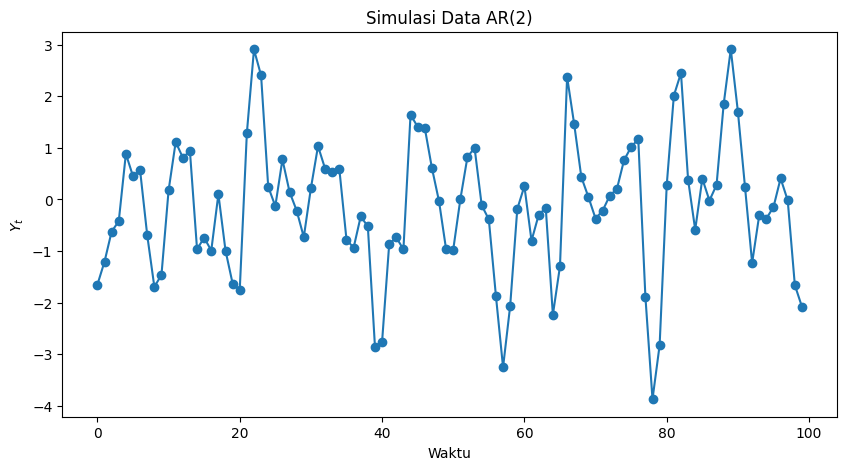

In [ ]:
np.random.seed(191)
phi1_ar2, phi2_ar2 = 0.9, -0.5

ar_params = np.array([1, -phi1_ar2, -phi2_ar2]) #nilai parameter theta dalam sintaks dituliskan sebagai negatif dari nilai parameter asli
ma_params = np.array([1])

ar_object2 = ArmaProcess(ar_params, ma_params)
ar2_s = ar_object2.generate_sample(nsample=100)

plt.figure(figsize=(10,5))
plt.plot(ar2_s,'-o')
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.title(f'Simulasi Data AR(2)')
plt.show()

**2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).**

Jumlah data latih: 80
Jumlah data uji: 20


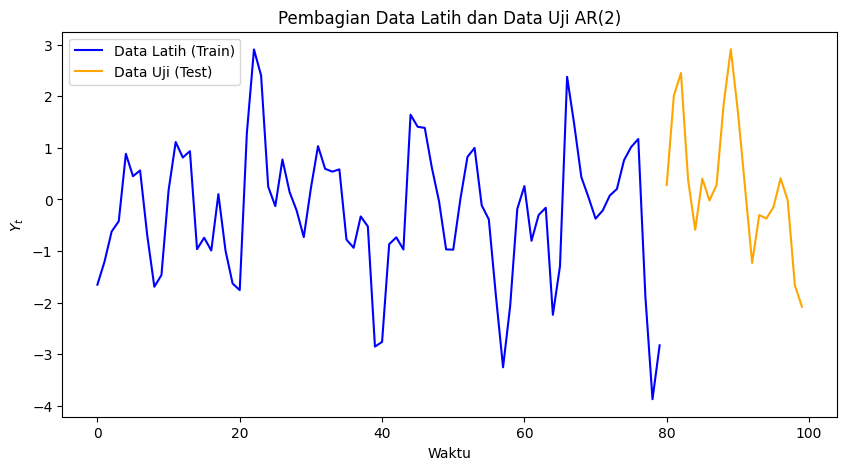

In [ ]:
# Menentukan proporsi pembagian data (misalnya 80% latih, 20% uji)
n_train_ar2 = int(len(ar2_s) * 0.8)

# Membagi deret waktu secara sekuensial
train_data_ar2 = ar2_s[:n_train_ar2]
test_data_ar2 = ar2_s[n_train_ar2:]

print(f"Jumlah data latih: {len(train_data_ar2)}")
print(f"Jumlah data uji: {len(test_data_ar2)}")

# Plot hasil pembagian data latih dan data uji
plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_train_ar2), train_data_ar2, label='Data Latih (Train)', color='blue')
plt.plot(np.arange(n_train_ar2, len(ar2_s)), test_data_ar2, label='Data Uji (Test)', color='orange')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.title('Pembagian Data Latih dan Data Uji AR(2)')
plt.legend()
plt.show()

**3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.**

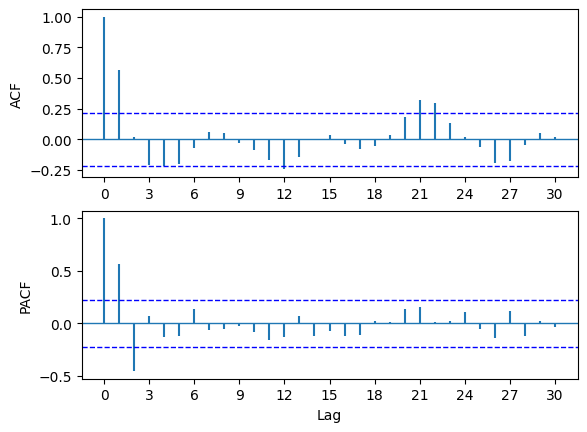

In [ ]:
from PythonTsa.plot_acf_pacf import acf_pacf_fig
import matplotlib.pyplot as plt

# Membuat plot ACF dan PACF dari data latih AR(2)
acf_pacf_fig(train_data_ar2, both=True, lag=30)
plt.show()

In [ ]:
%%R -i train_data_ar2

# Membuat plot EACF dari data latih
eacf(as.numeric(train_data_ar2))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x o o o o o o o o o o  x  o  o 
1 x o o o o o o o o o o  o  o  o 
2 o x o o o o o o o o o  x  o  o 
3 x o o x x o o o o o o  x  o  o 
4 x x o o x o o o o o o  o  o  o 
5 x o o o o o o o o o o  o  o  o 
6 x x o o o o o o o o o  o  o  o 
7 x o o o o o o o o o o  o  o  o 


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Melakukan pengepasan model AR(2) / ARIMA(2,0,0) pada data latih
model_ar2_fit = ARIMA(train_data_ar2, order=(2, 0, 0)).fit()

# Menampilkan ringkasan hasil model
print(model_ar2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -107.616
Date:                Wed, 23 Sep 2026   AIC                            223.232
Time:                        03:20:34   BIC                            232.760
Sample:                             0   HQIC                           227.052
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2369      0.170     -1.396      0.163      -0.569       0.096
ar.L1          0.8517      0.110      7.748      0.000       0.636       1.067
ar.L2         -0.4745      0.114     -4.165      0.0

**4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.**

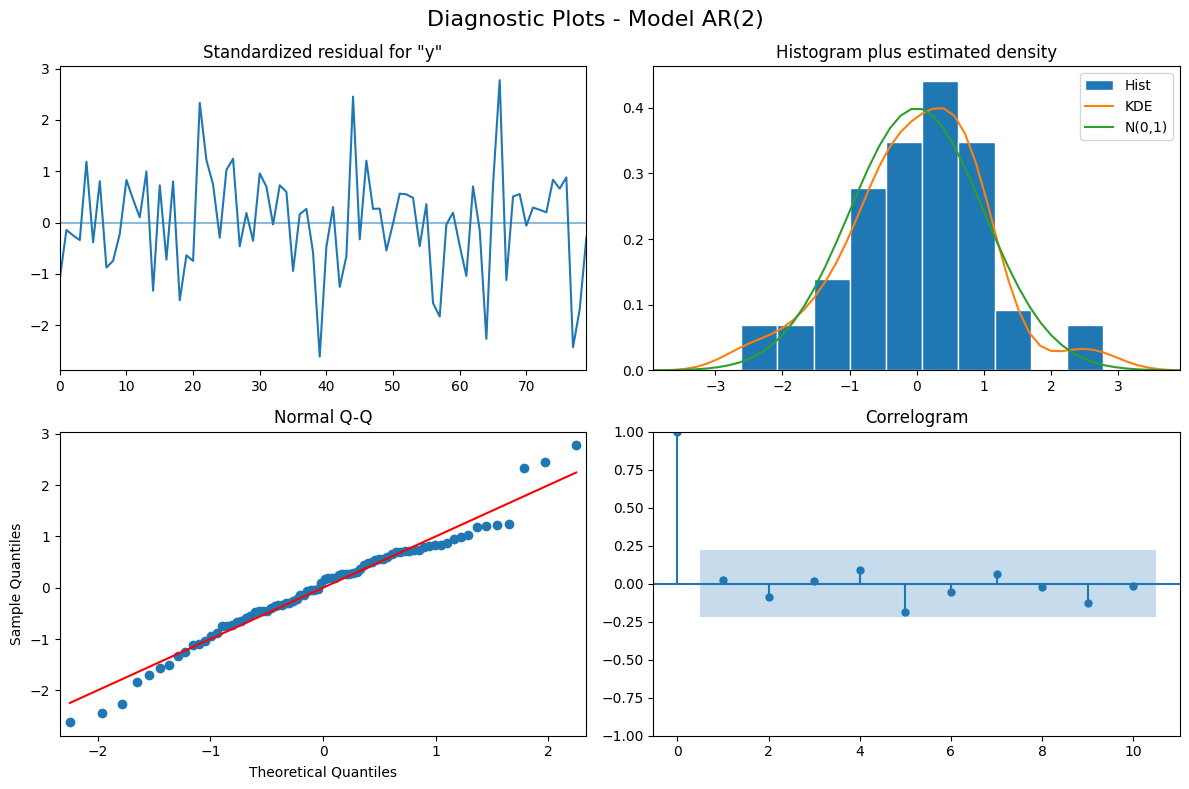

--- Hasil Overfitting ke AR(3) ---
[1.72945871e-01 2.37675687e-14 3.07474620e-04 6.75946240e-01
 1.00568405e-09]

--- Hasil Overfitting ke ARMA(2,1) ---
[1.76202631e-01 6.57206893e-03 5.51877728e-02 4.92753003e-01
 1.44441504e-09]

--- Perbandingan Kriteria Kebaikan Model ---
                   Model        AIC        BIC
    AR(2) / ARIMA(2,0,0) 223.232227 232.760334
    AR(3) / ARIMA(3,0,0) 225.029167 236.939301
ARMA(2,1) / ARIMA(2,0,1) 224.856728 236.766861


In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# ==========================================
# 1. Pengecekan Diagnostik Sisaan
# ==========================================
fig = model_ar2_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle('Diagnostic Plots - Model AR(2)', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 2. Overfitting (Pengepasan Model Berlebih)
# ==========================================
# Overfit ke AR(3) [ARIMA(3,0,0)] dan ARMA(2,1) [ARIMA(2,0,1)]
model_ar3 = ARIMA(train_data_ar2, order=(3, 0, 0)).fit()
model_arma21_overfit = ARIMA(train_data_ar2, order=(2, 0, 1)).fit()

print("--- Hasil Overfitting ke AR(3) ---")
print(model_ar3.pvalues)

print("\n--- Hasil Overfitting ke ARMA(2,1) ---")
print(model_arma21_overfit.pvalues)


# ==========================================
# 3. Penentuan Model Terbaik (AIC & BIC)
# ==========================================
criteria_data_ar2 = {
    'Model': ['AR(2) / ARIMA(2,0,0)', 'AR(3) / ARIMA(3,0,0)', 'ARMA(2,1) / ARIMA(2,0,1)'],
    'AIC': [model_ar2_fit.aic, model_ar3.aic, model_arma21_overfit.aic],
    'BIC': [model_ar2_fit.bic, model_ar3.bic, model_arma21_overfit.bic]
}

df_criteria_ar2 = pd.DataFrame(criteria_data_ar2)
print("\n--- Perbandingan Kriteria Kebaikan Model ---")
print(df_criteria_ar2.to_string(index=False))

**5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.**

RMSE Data Latih : 0.9302
MAPE Data Latih : 313.5812%
RMSE Data Uji   : 1.2613
MAPE Data Uji   : 257.7850%


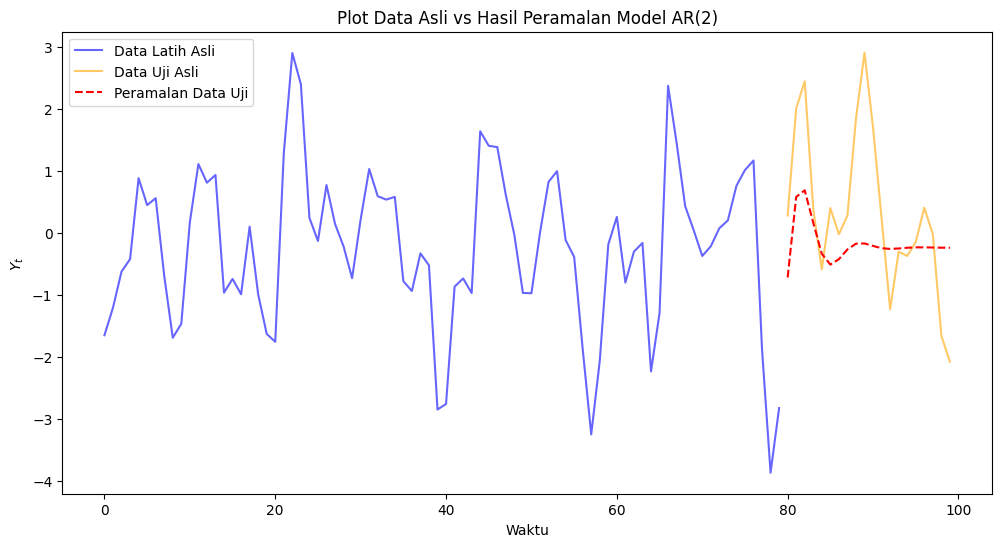

In [ ]:
import numpy as np

# 1. Peramalan (Forecasting)
# Prediksi untuk data latih
train_pred_ar2 = model_ar2_fit.fittedvalues

# Prediksi untuk data uji sebanyak jumlah data uji
test_pred_ar2 = model_ar2_fit.forecast(steps=len(test_data_ar2))

# 2. Fungsi Evaluasi Metrik
def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100

# Menghitung Metrik
rmse_train_ar2 = calculate_rmse(train_data_ar2, train_pred_ar2)
mape_train_ar2 = calculate_mape(train_data_ar2, train_pred_ar2)

rmse_test_ar2 = calculate_rmse(test_data_ar2, test_pred_ar2)
mape_test_ar2 = calculate_mape(test_data_ar2, test_pred_ar2)

print(f"RMSE Data Latih : {rmse_train_ar2:.4f}")
print(f"MAPE Data Latih : {mape_train_ar2:.4f}%")
print(f"RMSE Data Uji   : {rmse_test_ar2:.4f}")
print(f"MAPE Data Uji   : {mape_test_ar2:.4f}%")

# 3. Visualisasi Hasil Peramalan
plt.figure(figsize=(12, 6))
# Plot Data Asli
plt.plot(np.arange(len(train_data_ar2)), train_data_ar2, label='Data Latih Asli', color='blue', alpha=0.6)
plt.plot(np.arange(len(train_data_ar2), len(ar2_s)), test_data_ar2, label='Data Uji Asli', color='orange', alpha=0.6)

# Plot Hasil Prediksi (Hanya Data Uji)
plt.plot(np.arange(len(train_data_ar2), len(ar2_s)), test_pred_ar2, label='Peramalan Data Uji', color='red', linestyle='--')

plt.title('Plot Data Asli vs Hasil Peramalan Model AR(2)')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.legend()
plt.show()

**DERET ARMA(1,1)**

**1. Simulasikan deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.**

In [ ]:
np.random.seed(191)
ar1 = np.array([1,-0.4]) #nilai parameter phi dalam sintaks dituliskan sebagai negatif dari nilai parameter asli
ma1 = np.array([1,-0.6]) #nilai parameter theta dalam sintaks dituliskan sebagai negatif dari nilai parameter asli
arma_object1 = ArmaProcess(ar1,ma1)
arma1 = arma_object1.generate_sample(nsample=200)

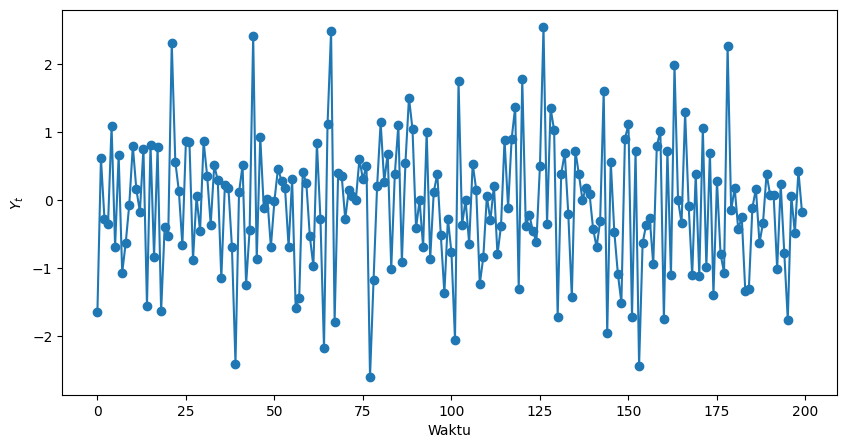

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(arma1,'-o')
plt.xlabel('Waktu'), plt.ylabel(r'$Y_t$')
plt.show()

**2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).**

Jumlah data latih: 160
Jumlah data uji: 40


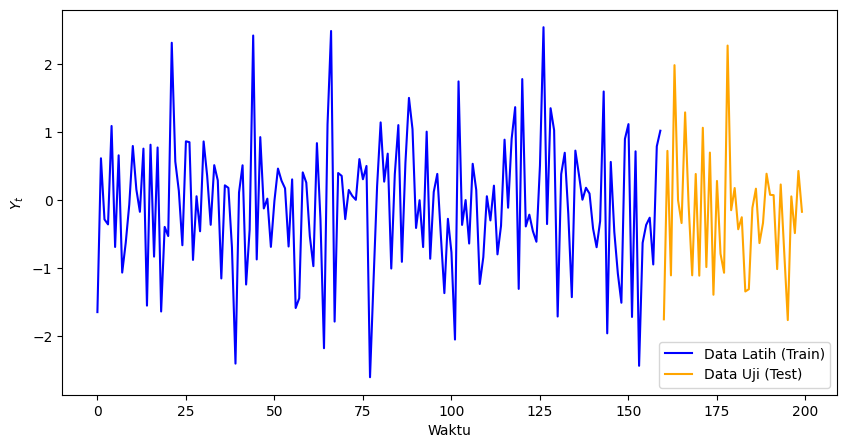

In [ ]:
# Menentukan proporsi pembagian data (80% latih, 20% uji)
n_train = int(len(arma1) * 0.8)

# Membagi deret waktu secara sekuensial
train_data_arma = arma1[:n_train]
test_data_arma = arma1[n_train:]

print(f"Jumlah data latih: {len(train_data_arma)}")
print(f"Jumlah data uji: {len(test_data_arma)}")

# Plot hasil pembagian data latih dan data uji
plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_train), train_data_arma, label='Data Latih (Train)', color='blue')
plt.plot(np.arange(n_train, len(arma1)), test_data_arma, label='Data Uji (Test)', color='orange')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.legend()
plt.show()

Karena pola data testing dan training terpotong saat kondisi data curam dan tidak stabil, maka dicoba pembagian 70%-30%.

Jumlah data latih: 140
Jumlah data uji: 60


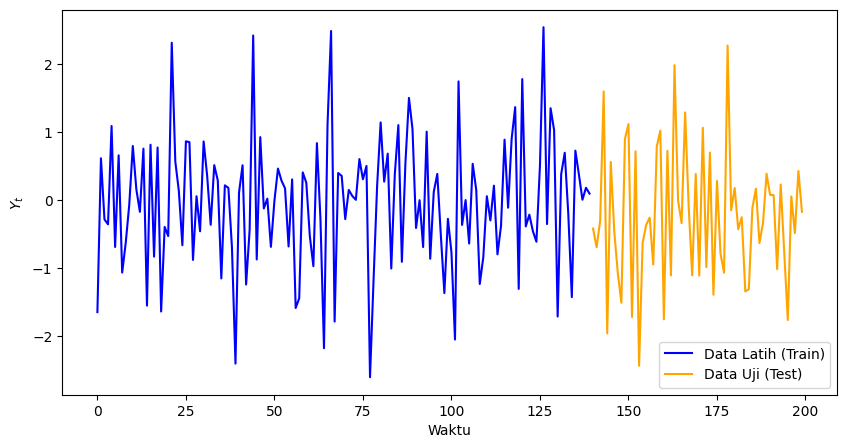

In [ ]:
# Menentukan proporsi pembagian data (70% latih, 30% uji)
n_train = int(len(arma1) * 0.7)

# Membagi deret waktu secara sekuensial
train_data_arma = arma1[:n_train]
test_data_arma = arma1[n_train:]

print(f"Jumlah data latih: {len(train_data_arma)}")
print(f"Jumlah data uji: {len(test_data_arma)}")

# Plot hasil pembagian data latih dan data uji
plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_train), train_data_arma, label='Data Latih (Train)', color='blue')
plt.plot(np.arange(n_train, len(arma1)), test_data_arma, label='Data Uji (Test)', color='orange')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.legend()
plt.show()

**3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latih.**

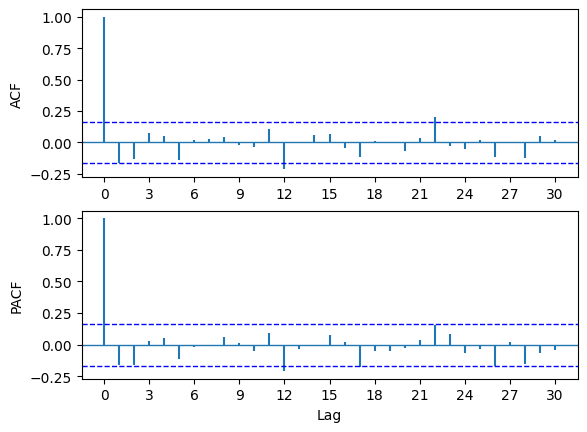

In [ ]:
from PythonTsa.plot_acf_pacf import acf_pacf_fig
import matplotlib.pyplot as plt

# Membuat plot ACF dan PACF dari data latih ARMA(1,1)
acf_pacf_fig(train_data_arma, both=True, lag=30)
plt.show()

In [ ]:
%%R -i train_data_arma

# Membuat plot EACF dari data latih
eacf(as.numeric(train_data_arma))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 o o o o o o o o o o o  x  o  o 
1 x x o o o o o o o o o  x  o  o 
2 o x o o o o o o o o o  x  o  o 
3 x o x o o o o o o o o  x  o  o 
4 x x x x o o o o o o o  x  o  o 
5 o o x o x o o o o o o  o  o  o 
6 x o x o o o o o o o o  o  o  o 
7 x x o o o o o o o o o  o  o  o 


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Melakukan pengepasan model ARMA(1,1) / ARIMA(1,0,1) pada data latih
model_arma_fit = ARIMA(train_data_arma, order=(1, 0, 1)).fit()

# Menampilkan ringkasan hasil model
print(model_arma_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  140
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -188.281
Date:                Wed, 23 Sep 2026   AIC                            384.561
Time:                        03:20:38   BIC                            396.328
Sample:                             0   HQIC                           389.343
                                - 140                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0307      0.057     -0.538      0.591      -0.142       0.081
ar.L1          0.2977      0.362      0.822      0.411      -0.412       1.007
ma.L1         -0.4989      0.319     -1.565      0.1

**4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.**

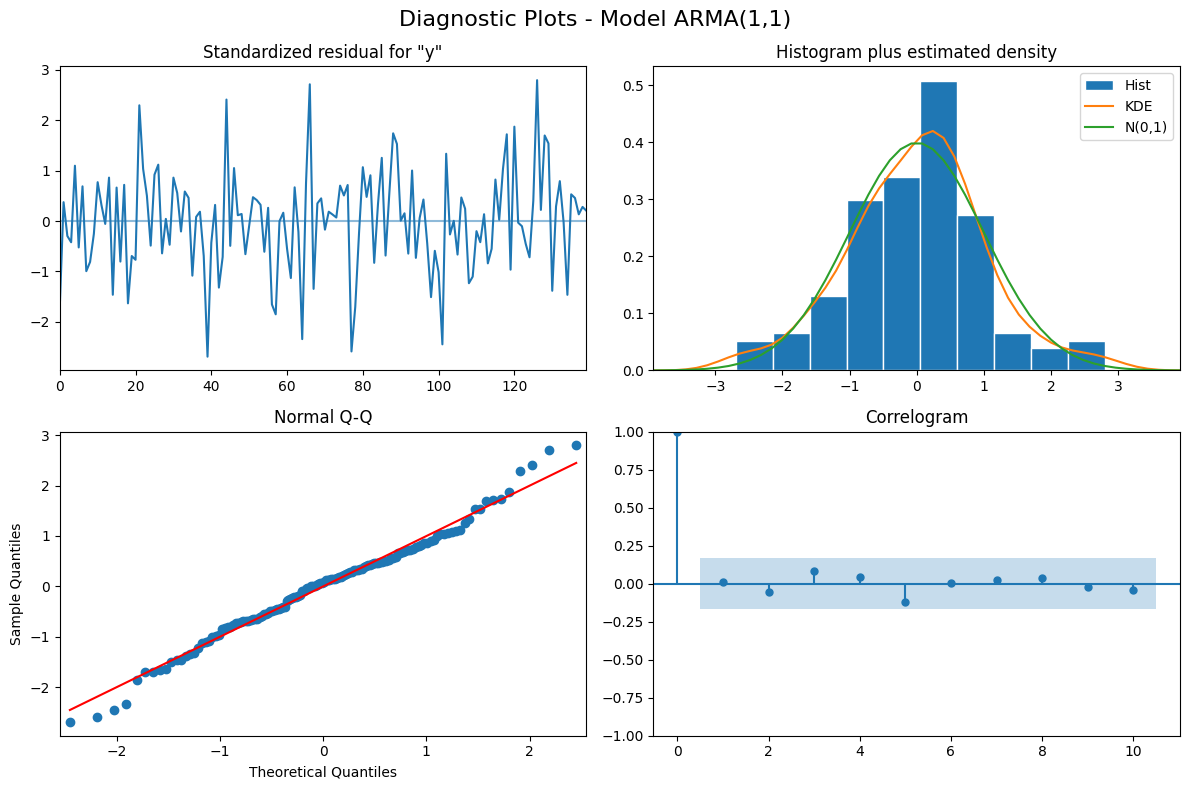

--- Hasil Overfitting ke ARMA(2,1) ---
[6.00982314e-01 6.03205202e-01 1.67419558e-01 8.62260674e-01
 2.94854082e-18]

--- Hasil Overfitting ke ARMA(1,2) ---
[5.93541064e-01 7.55715585e-01 9.38805149e-01 3.72580399e-01
 1.78952526e-18]

--- Perbandingan Kriteria Kebaikan Model ---
    Model        AIC        BIC
ARMA(1,1) 384.561499 396.328069
ARMA(2,1) 385.117289 399.825501
ARMA(1,2) 385.687893 400.396105
ARMA(2,2) 382.487522 400.137376


In [ ]:
import pandas as pd

# ==========================================
# 1. Pengecekan Diagnostik Sisaan
# ==========================================
fig = model_arma_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle('Diagnostic Plots - Model ARMA(1,1)', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 2. Overfitting (Pengepasan Model Berlebih)
# ==========================================
# Overfit ke ARMA(2,1) [ARIMA(2,0,1)] dan ARMA(1,2) [ARIMA(1,0,2)]
model_arma21 = ARIMA(train_data_arma, order=(2, 0, 1)).fit()
model_arma12 = ARIMA(train_data_arma, order=(1, 0, 2)).fit()
model_arma22 = ARIMA(train_data_arma, order=(2, 0, 2)).fit()

print("--- Hasil Overfitting ke ARMA(2,1) ---")
print(model_arma21.pvalues)

print("\n--- Hasil Overfitting ke ARMA(1,2) ---")
print(model_arma12.pvalues)


# ==========================================
# 3. Penentuan Model Terbaik (AIC & BIC)
# ==========================================
criteria_data_arma = {
    'Model': ['ARMA(1,1)', 'ARMA(2,1)', 'ARMA(1,2)', 'ARMA(2,2)'],
    'AIC': [model_arma_fit.aic, model_arma21.aic, model_arma12.aic, model_arma22.aic],
    'BIC': [model_arma_fit.bic, model_arma21.bic, model_arma12.bic, model_arma22.bic]
}

df_criteria_arma = pd.DataFrame(criteria_data_arma)
print("\n--- Perbandingan Kriteria Kebaikan Model ---")
print(df_criteria_arma.to_string(index=False))

**5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.**

RMSE Data Latih : 0.9288
MAPE Data Latih : 442.0728%
RMSE Data Uji   : 0.9950
MAPE Data Uji   : 108.3042%


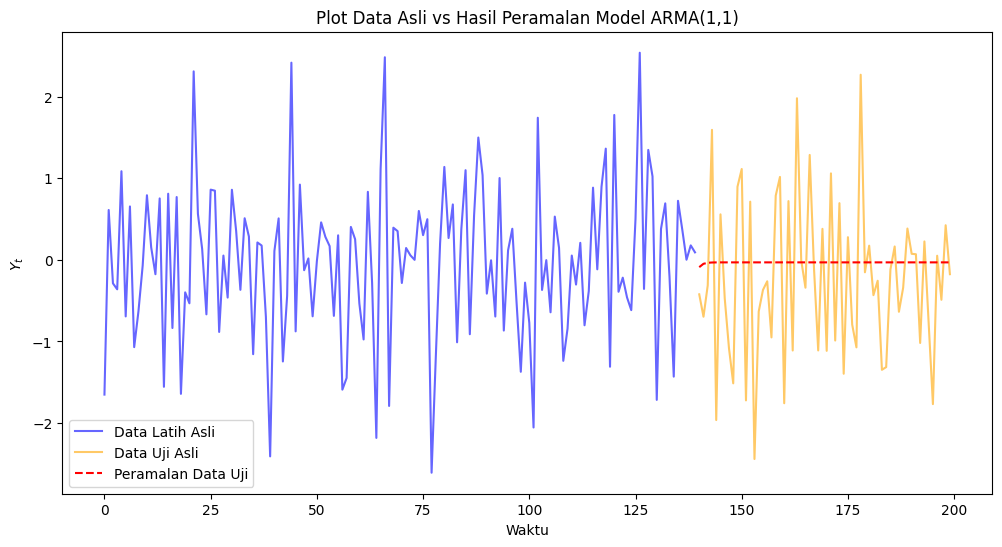

In [ ]:
import numpy as np

# 1. Peramalan (Forecasting)
# Prediksi untuk data latih
train_pred_arma = model_arma_fit.fittedvalues

# Prediksi untuk data uji sebanyak jumlah data uji (60 periode)
test_pred_arma = model_arma_fit.forecast(steps=len(test_data_arma))

# 2. Fungsi Evaluasi Metrik
def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100

# Menghitung Metrik
rmse_train_arma = calculate_rmse(train_data_arma, train_pred_arma)
mape_train_arma = calculate_mape(train_data_arma, train_pred_arma)

rmse_test_arma = calculate_rmse(test_data_arma, test_pred_arma)
mape_test_arma = calculate_mape(test_data_arma, test_pred_arma)

print(f"RMSE Data Latih : {rmse_train_arma:.4f}")
print(f"MAPE Data Latih : {mape_train_arma:.4f}%")
print(f"RMSE Data Uji   : {rmse_test_arma:.4f}")
print(f"MAPE Data Uji   : {mape_test_arma:.4f}%")

# 3. Visualisasi Hasil Peramalan
plt.figure(figsize=(12, 6))
# Plot Data Asli
plt.plot(np.arange(len(train_data_arma)), train_data_arma, label='Data Latih Asli', color='blue', alpha=0.6)
plt.plot(np.arange(len(train_data_arma), len(arma1)), test_data_arma, label='Data Uji Asli', color='orange', alpha=0.6)

# Plot Hasil Prediksi (Hanya Data Uji)
plt.plot(np.arange(len(train_data_arma), len(arma1)), test_pred_arma, label='Peramalan Data Uji', color='red', linestyle='--')

plt.title('Plot Data Asli vs Hasil Peramalan Model ARMA(1,1)')
plt.xlabel('Waktu')
plt.ylabel(r'$Y_t$')
plt.legend()
plt.show()